Reference actually
Read data from server, plot diodes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import psana
from psana import MPIDataSource, Detector
import h5py

# Load the intensity
Filter based on ipm2

In [2]:
run_num = 391 # check Run 475
# Define parameters
exp_name = 'xppl1016922'
smalldata_path = '/sdf/data/lcls/ds/xpp/{}/hdf5/smalldata/'.format(exp_name)
smalldata_path

'/sdf/data/lcls/ds/xpp/xppl1016922/hdf5/smalldata/'

In [8]:
# Load the result from droplet analysis
with h5py.File(smalldata_path + '{}_Run{:04d}.h5'.format(exp_name, run_num),'r') as f:
    ebeam = np.array(f['ebeam']['photon_energy'])
    sample_diode = f['diodeU']['channels'][:,1] # down stream intensity
    cc = np.array(f['ai/ch03']) # shutter > 4 means open
    vcc = np.array(f['ai/ch02']) # shutter > 4 means open
    ipm2 = np.array(f['ipm2/sum'])  # intensity  # use this for filtering, upstream intensity
    d1 = np.array(f['diode2/channels'][:,0]) # intensity
    d5 = np.array(f['diodeU/channels'][:,3])# intensity
    d6 = np.array(f['lombpm/channels'][:,2])# intensity
   
    #print(f['/epicsOnce'].keys())
    #print(f['/'].keys())


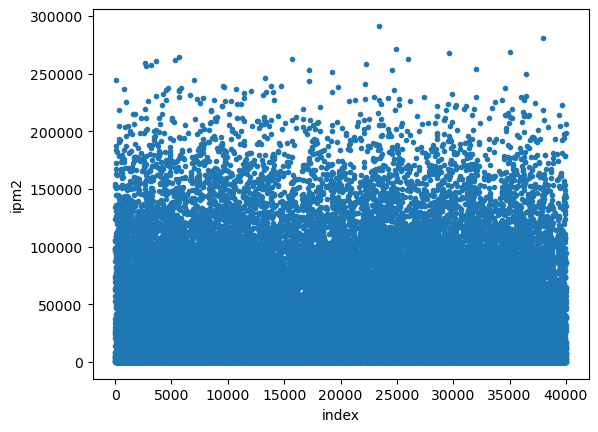

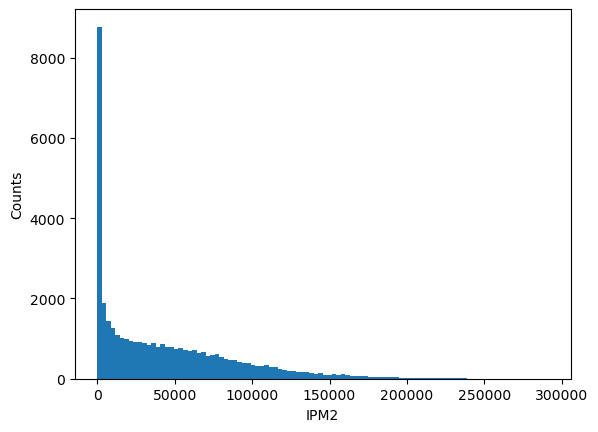

threshold = 183303.59750000024
ipm2 shape = (40003,)
mask shape = (39602,)


In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ipm2, '.')
plt.xlabel('index')
plt.ylabel('ipm2')
plt.show()

plt.figure()
plt.hist(ipm2, 100)
plt.xlabel('IPM2')
plt.ylabel('Counts')
plt.show()

# threshold for top 1% highest values
thr_high = np.percentile(ipm2, 99)

# indices excluding top 1%
mask_ipm2 = np.where(ipm2 < thr_high)[0]

print("threshold =", thr_high)
print("ipm2 shape =", np.shape(ipm2))
print("mask shape =", np.shape(mask_ipm2))

In [14]:

ds = MPIDataSource('exp=xppl1016922:run={}:smd'.format(run_num))
detname = 'jungfrau1M_alcove'
det = Detector(detname) 
nimg = 100 # max
img_num = 0
imgs = []
sumimg=np.zeros((1064,1030))
for nevt,evt in enumerate(ds.events()):
    #if nevt == nimg: break
    #i0s[nevt] = det_i0.get(evt).TotalIntensity()
    tmp=[]
    if nevt in mask_ipm2:
        img = det.image(evt)
        imgs.append(np.copy(img))
        tmp=np.copy(img)
        tmp[tmp<0]=0
        sumimg = sumimg + tmp
        img_num += 1
    if img_num == nimg: break
s = 'r' +str(run_num) +'data= sumimg'


# Load images

In [14]:

ds = MPIDataSource('exp=xppl1016922:run={}:smd'.format(run_num))
detname = 'jungfrau1M_alcove'
det = Detector(detname) 
nimg = 100 # max
img_num = 0
imgs = []
sumimg=np.zeros((1064,1030))
for nevt,evt in enumerate(ds.events()):
    #if nevt == nimg: break
    #i0s[nevt] = det_i0.get(evt).TotalIntensity()
    tmp=[]
    if nevt in mask_ipm2:
        img = det.image(evt)
        imgs.append(np.copy(img))
        tmp=np.copy(img)
        tmp[tmp<0]=0
        sumimg = sumimg + tmp
        img_num += 1
    if img_num == nimg: break
s = 'r' +str(run_num) +'data= sumimg'


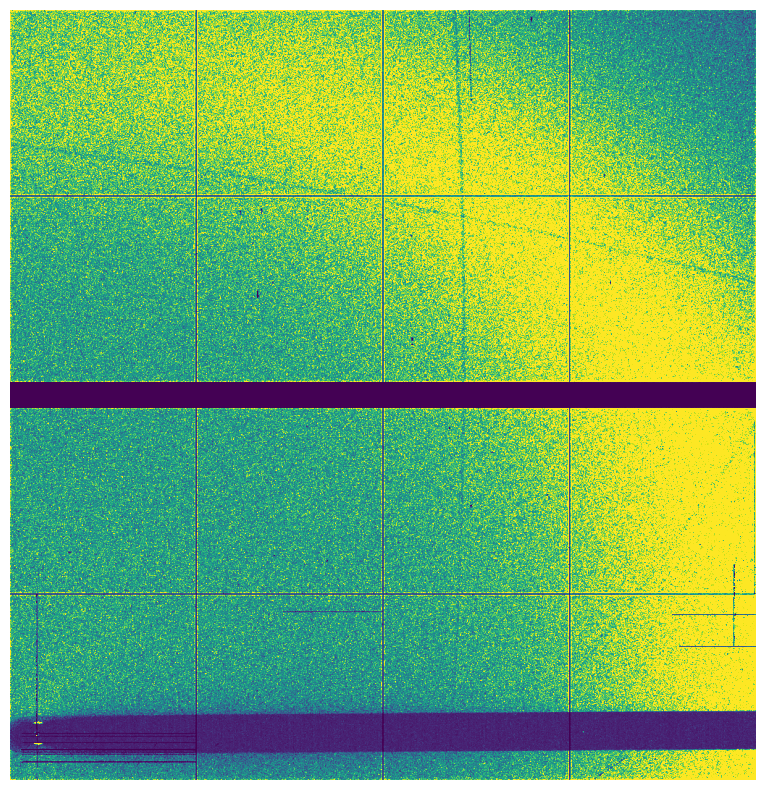

In [11]:
plt.figure(figsize=(10,10));plt.imshow(sumimg,vmin=1.5,vmax=100)
plt.axis('off')
plt.savefig(f'run{run_num}.png',bbox_inches='tight', pad_inches=0)